In [21]:
#!/usr/bin/env python3
"""
Utilities to make two plots from a CSV file:
 - CLIP scores (top-1/2/3) with ±1 std
 - BERT scores (top-1/2/3) with ±1 std

Expected CSV columns, e.g.:

n,bert@1_mean,bert@1_std,clip@1_mean,clip@1_std,...
0,0.904601,0.033577,0.506583,0.025467,...
...
"""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def plot_group(df, prefix, title, ylabel, save_path=None):
    """
    Plot mean ± std for prefix in {'bert', 'clip'} for top-1/2/3.

    Columns must be named like:
        f'{prefix}@1_mean', f'{prefix}@1_std', ... '@2_', '@3_'.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the metrics.
    prefix : str
        'bert' or 'clip'.
    title : str
        Title of the plot.
    ylabel : str
        Label for the y-axis.
    save_path : str or Path or None
        If given, save the figure to this path.
    """
    if "n" not in df.columns:
        raise ValueError("DataFrame must contain an 'n' column for the x-axis.")

    # Ensure sorted by n
    df = df.sort_values("n")
    x = df["n"].values

    plt.figure()
    for k in [1, 2, 3]:
        mean_col = f"{prefix}@{k}_mean"
        std_col = f"{prefix}@{k}_std"

        if mean_col not in df.columns or std_col not in df.columns:
            # Skip if this column is not present
            continue

        mean = df[mean_col].values
        std = df[std_col].values

        line, = plt.plot(x, mean, label=f"{prefix.upper()}@{k} mean")
        color = line.get_color()
        plt.fill_between(x, mean - std, mean + std, alpha=0.15)

    plt.xlabel("Norm Layer")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200)
        print(f"Saved {save_path}")

    plt.show()
    plt.close()


def load_metrics_csv(csv_path):
    """
    Load the metrics CSV file into a pandas DataFrame.

    Parameters
    ----------
    csv_path : str or Path
        Path to the CSV file.

    Returns
    -------
    df : pandas.DataFrame
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)
    return df


def plot_metrics_from_csv(
    csv_path,
    out_dir=None,
    clip_filename="clip_scores.pdf",
    bert_filename="bert_scores.pdf",
):
    """
    Convenience wrapper: load CSV, then plot CLIP and BERT groups.

    Parameters
    ----------
    csv_path : str or Path
        Path to CSV file with metrics.
    out_dir : str or Path or None
        If given, save figures into this directory.
        If None, just display inline.
    clip_filename : str
        Filename for CLIP plot (when out_dir is not None).
    bert_filename : str
        Filename for BERT plot (when out_dir is not None).
    """
    df = load_metrics_csv(csv_path)

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        clip_path = out_dir / clip_filename
        bert_path = out_dir / bert_filename
    else:
        clip_path = None
        bert_path = None

    # Plot CLIP scores
    plot_group(
        df,
        prefix="clip",
        title="CLIP@1/2/3 scores with ±std",
        ylabel="CLIP score",
        save_path=clip_path,
    )

    # Plot BERT scores
    plot_group(
        df,
        prefix="bert",
        title="BERT@1/2/3 scores with std",
        ylabel="BERTScore",
        save_path=bert_path,
    )

    return df  # useful if you want to inspect the DataFrame


Saved /mnt/abka03/Projects/xl-vlms/outputs/ablation/layers/clip_scores.pdf


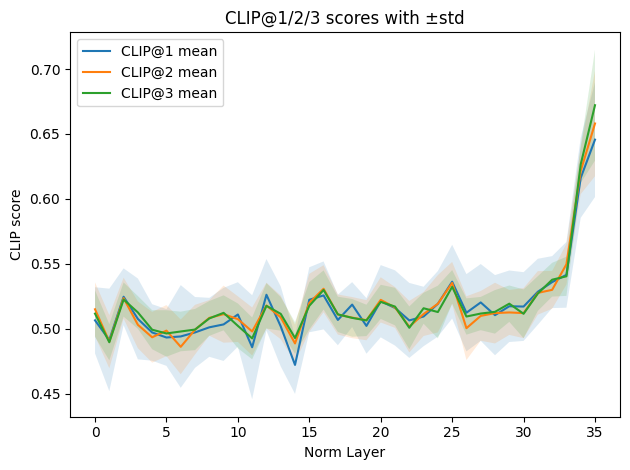

Saved /mnt/abka03/Projects/xl-vlms/outputs/ablation/layers/bert_scores.pdf


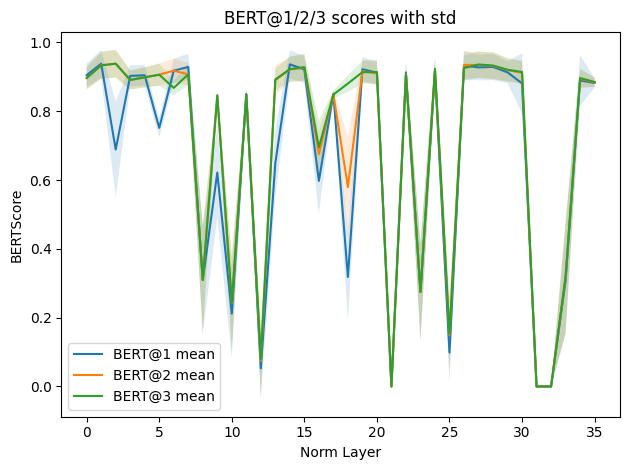

In [22]:
# 1. Put the code above in a cell and run it.

# 2. Then call:
json_path = "/mnt/abka03/Projects/xl-vlms/outputs/ablation/layers/n_eval_snmf.csv"

df = plot_metrics_from_csv(
    json_path,
    out_dir="/mnt/abka03/Projects/xl-vlms/outputs/ablation/layers",
)

